In [97]:
import pandas as pd
import time
import sqlite3
import logging
import json
import os
from datetime import datetime
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import association_rules, fpgrowth

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score
import joblib

RANDOM_STATE = 42

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# **1. Сбор данных**

In [98]:
BATCH_SIZE = 5120

#сбор потоковых данных
def create_batches_stream(df, batch_size, interval=0.1):
  for i in range(0, len(df), batch_size):
    batch = df[i:i+batch_size]
    time.sleep(interval)
    yield batch

In [99]:
#разработка хранилища сырых данных БД
# conn = sqlite3.connect('motor_data.db')
def create_data_base(df, conn, create_table=False):
  if create_table:
    df.head(0).to_sql('data', conn, if_exists='replace', index=False)
  cursor = conn.cursor()
  for batch in create_batches_stream(df, BATCH_SIZE, interval=1):
    try:
      batch.to_sql('data', conn, if_exists='append', index=False)
      logging.info(f'Батч добавлен, размер={len(batch)}')
    except Exception as e:
      logging.error(f'Ошибка при добавлении: {e}')
      raise
  conn.commit()

In [100]:
#система логирования
logging.basicConfig(level=logging.INFO, filename='motor_data.log', filemode='w',
                    format='%(asctime)s - %(levelname)s - %(message)s')

#обработка ошибок
#обработка загрузки данных
try:
  motor_data_11_14 = pd.read_csv('motor_data11-14lats.csv')
  logging.info(f'Данные успешно загружены:{motor_data_11_14.shape}')
except Exception as e:
  logging.error(f'Ошибка при загрузке данных: {e}')
  raise

#подключение к БД
try:
  conn = sqlite3.connect('motor_data.db')
  logging.info('Успешно подключено к базе данных')
except Exception as e:
  logging.error(f'Ошибка при подключении к базе данных: {e}')
  raise

#добавление данных в БД
try:
  create_data_base(motor_data_11_14, conn)
  logging.info('Успешно добавлено в базу данных')
except Exception as e:
  logging.error(f'Ошибка при добавлении в базу данных: {e}')
  raise

**Расчет метапараметров**

In [63]:
def calculate_metadata(df):
    meta = {
        "rows": len(df),
        "columns": df.shape[1],
        "column_names": list(df.columns),
        "dtypes": df.dtypes.astype(str).to_dict(),
        "missing_values": df.isnull().sum().astype(int).to_dict(),
        "unique_values": df.nunique().astype(int).to_dict()
    }

    # статистика для числовых колонок
    meta["numeric_stats"] = df.describe().to_dict()
    meta["duplicate_rows"] = int(df.duplicated().sum())

    return meta

meta1 = calculate_metadata(motor_data_11_14)
# meta2 = calculate_metadata(motor_data_14_18)

with open("metadata_11_14.json", "w") as f:
    json.dump(meta1, f, indent=4)

# with open("metadata_14_18.json", "w") as f:
#     json.dump(meta2, f, indent=4)


# **2. Анализ данных**

# **2.1 Data quality**

In [64]:
motor_data_11_14.head()

,SEX,INSR_BEGIN,INSR_END,EFFECTIVE_YR,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID
0,0,08-AUG-13,07-AUG-14,08,1202,519755.22,7209.140,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
1,0,08-AUG-12,07-AUG-13,08,1202,519755.22,7203.890,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
2,0,08-AUG-11,07-AUG-12,08,1202,519755.22,7045.804,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
3,0,08-JUL-11,07-AUG-11,08,1202,519755.22,287.250,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
4,0,08-AUG-13,07-AUG-14,08,1202,285451.24,4286.900,5000029901,2010.0,4.0,7.0,Pick-up,2494.0,TOYOTA,Own Goods,19894.43


In [65]:
motor_data_11_14.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293537 entries, 0 to 293536
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                293537 non-null  int64  
 1   INSR_BEGIN         293537 non-null  object 
 2   INSR_END           293537 non-null  object 
 3   EFFECTIVE_YR       293536 non-null  object 
 4   INSR_TYPE          293537 non-null  int64  
 5   INSURED_VALUE      293537 non-null  float64
 6   PREMIUM            293529 non-null  float64
 7   OBJECT_ID          293537 non-null  int64  
 8   PROD_YEAR          293431 non-null  float64
 9   SEATS_NUM          293397 non-null  float64
 10  CARRYING_CAPACITY  212172 non-null  float64
 11  TYPE_VEHICLE       293537 non-null  object 
 12  CCM_TON            293535 non-null  float64
 13  MAKE               293537 non-null  object 
 14  USAGE              293537 non-null  object 
 15  CLAIM_PAID         22373 non-null   float64
dtypes:

In [66]:
class DataQualityEvaluator:

    @staticmethod
    def completeness(df):
        df_bin = df.isna()

        cols_nan_ratio = df_bin.sum(axis=0) / df.shape[0]
        rows_nan_ratio = df_bin.sum(axis=1) / df.shape[1]

        return {
            "full": df_bin.sum().sum() / np.prod(df.shape),
            "cols_max": cols_nan_ratio.max(),
            "rows_max": rows_nan_ratio.max()
        }

    @staticmethod
    def validity(df):
        checks = {}

        for col in ["PREMIUM", "INSURED_VALUE", "CLAIM_PAID", "SEATS_NUM"]:
            if col in df.columns:
                checks[col] = not ((df[col] < 0).any())

        return checks

    @staticmethod
    def timeliness(df):
        if "INSR_BEGIN" not in df.columns:
            return {"delta_time_max": None}

        dates = pd.to_datetime(df["INSR_BEGIN"], format='%d-%m-%y', errors="coerce")
        dates = dates.dropna().sort_values().unique()

        if len(dates) < 2:
            return {"delta_time_max": 0}

        max_time_lag = np.diff(dates).max()
        max_time_lag = max_time_lag.astype('timedelta64[D]').astype(int)

        return {"delta_time_max": max_time_lag}

    @staticmethod
    def uniqueness(df):
        return {
            "duplicates": df.duplicated().sum()
        }

    @staticmethod
    def accuracy(df):
        checks = {}

        # даты
        try:
            begin = pd.to_datetime(df["INSR_BEGIN"], format='%d-%m-%y', errors="coerce")
            end = pd.to_datetime(df["INSR_END"], format='%d-%m-%y', errors="coerce")
            checks["date_order"] = (end >= begin).mean()
        except:
            checks["date_order"] = None

        # год выпуска
        current_year = datetime.now().year
        if "PROD_YEAR" in df.columns:
            valid_year = df["PROD_YEAR"].between(1900, current_year)
            checks["prod_year_valid"] = valid_year.mean()

        # премия и стоимость
        checks["premium_positive"] = (df["PREMIUM"] >= 0).mean()
        checks["insured_value_positive"] = (df["INSURED_VALUE"] >= 0).mean()

        return checks

In [67]:
quality_m = vars(DataQualityEvaluator)

methods = {
    name: func for name, func in quality_m.items()
    if callable(func)
}

meta = {}

for name, func in methods.items():
    result = func(motor_data_11_14)
    meta.update({f"{name}({k})": v for k, v in result.items()})

print(meta)

{'completeness(full)': np.float64(0.07511531766012462), 'completeness(cols_max)': 0.9237813290999091, 'completeness(rows_max)': 0.3125, 'validity(PREMIUM)': True, 'validity(INSURED_VALUE)': True, 'validity(CLAIM_PAID)': True, 'validity(SEATS_NUM)': True, 'timeliness(delta_time_max)': 0, 'uniqueness(duplicates)': np.int64(120), 'accuracy(date_order)': np.float64(0.0), 'accuracy(prod_year_valid)': np.float64(0.9996388870908949), 'accuracy(premium_positive)': np.float64(0.9999727461955392), 'accuracy(insured_value_positive)': np.float64(1.0)}


# **2.1 Базовая отчистка данных + EDA**

In [68]:
motor_data_11_14_copy = motor_data_11_14.copy()
motor_data_11_14_copy = motor_data_11_14_copy.drop_duplicates()
motor_data_11_14_copy.head()

,SEX,INSR_BEGIN,INSR_END,EFFECTIVE_YR,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID
0,0,08-AUG-13,07-AUG-14,08,1202,519755.22,7209.140,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
1,0,08-AUG-12,07-AUG-13,08,1202,519755.22,7203.890,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
2,0,08-AUG-11,07-AUG-12,08,1202,519755.22,7045.804,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
3,0,08-JUL-11,07-AUG-11,08,1202,519755.22,287.250,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
4,0,08-AUG-13,07-AUG-14,08,1202,285451.24,4286.900,5000029901,2010.0,4.0,7.0,Pick-up,2494.0,TOYOTA,Own Goods,19894.43


In [69]:
motor_data_11_14_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 293417 entries, 0 to 293536
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                293417 non-null  int64  
 1   INSR_BEGIN         293417 non-null  object 
 2   INSR_END           293417 non-null  object 
 3   EFFECTIVE_YR       293416 non-null  object 
 4   INSR_TYPE          293417 non-null  int64  
 5   INSURED_VALUE      293417 non-null  float64
 6   PREMIUM            293409 non-null  float64
 7   OBJECT_ID          293417 non-null  int64  
 8   PROD_YEAR          293311 non-null  float64
 9   SEATS_NUM          293277 non-null  float64
 10  CARRYING_CAPACITY  212078 non-null  float64
 11  TYPE_VEHICLE       293417 non-null  object 
 12  CCM_TON            293415 non-null  float64
 13  MAKE               293417 non-null  object 
 14  USAGE              293417 non-null  object 
 15  CLAIM_PAID         22373 non-null   float64
dtypes: floa

In [70]:
motor_data_11_14_copy.describe()

,SEX,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,CCM_TON,CLAIM_PAID
count,293417.000000,293417.000000,2.934170e+05,293409.000000,2.934170e+05,293311.000000,293277.000000,212078.000000,293415.000000,2.237300e+04
mean,0.510032,1201.714243,4.146758e+05,6477.284624,5.000237e+09,2001.394738,6.182657,648.300165,3304.331686,2.791407e+05
std,0.645339,0.455494,8.355149e+05,9040.684427,1.684094e+05,10.305470,13.046853,4839.801630,3499.416143,2.008516e+06
min,0.000000,1201.000000,0.000000e+00,0.000000,5.000018e+09,1950.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,1201.000000,0.000000e+00,804.850000,5.000096e+09,1995.000000,1.000000,0.000000,997.000000,1.169195e+04
50%,0.000000,1202.000000,2.000000e+05,3156.030000,5.000198e+09,2005.000000,4.000000,7.000000,2494.000000,3.107954e+04
75%,1.000000,1202.000000,5.856992e+05,8293.213000,5.000344e+09,2010.000000,4.000000,75.000000,4164.000000,1.321040e+05
max,2.000000,1204.000000,2.500000e+08,227278.880000,5.000949e+09,2018.000000,199.000000,1000000.000000,20000.000000,1.524458e+08


Можно заметить, что в числовых данных присутствуют пропуски, поэтому их лучше заменить на медианное значение. Также можно заметить, что в некоторых столбцах присутствуют экстремальные значения, например, количество сидений в автомобиле, максимальное значение - 199, но если взять доже самый большой автобус, в нем будет около 100 посадочных мест. Поэтому нужно изучить выбросы в данных.

In [71]:
motor_data_11_14_copy = motor_data_11_14_copy[motor_data_11_14_copy['SEATS_NUM'] <= 100]

In [72]:
categorical_cols = ['SEX', 'TYPE_VEHICLE', 'MAKE', 'USAGE']
for col in categorical_cols:
    print(f"{col}: {motor_data_11_14_copy[col].nunique()}")

SEX: 3
TYPE_VEHICLE: 11
MAKE: 455
USAGE: 14


In [73]:
numeric_cols = ['PREMIUM', 'INSURED_VALUE', 'SEATS_NUM', 'CARRYING_CAPACITY', 'CCM_TON', "PROD_YEAR"]
for col in numeric_cols:
    motor_data_11_14_copy[col] = motor_data_11_14_copy[col].fillna(motor_data_11_14_copy[col].median())

Так как в столбце 'CLAIM_PAID' только 22373 строк не имеют пропуски, поэтому заполнять медианной будет некорректно

In [74]:
motor_data_11_14_copy['CLAIM_PAID'] = motor_data_11_14_copy['CLAIM_PAID'].fillna(0)

In [75]:
#межквартильный размах
def IQR(df, column):
  Q1 = np.quantile(df[column], 0.25)
  Q3 = np.quantile(df[column], 0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  return (lower_bound, upper_bound)

Колонка 'PREMIUM':
Нижняя граница: -10332.99, верхняя граница: 19367.92
Число выбросов: 24277 из 292434 строк (8.30%)



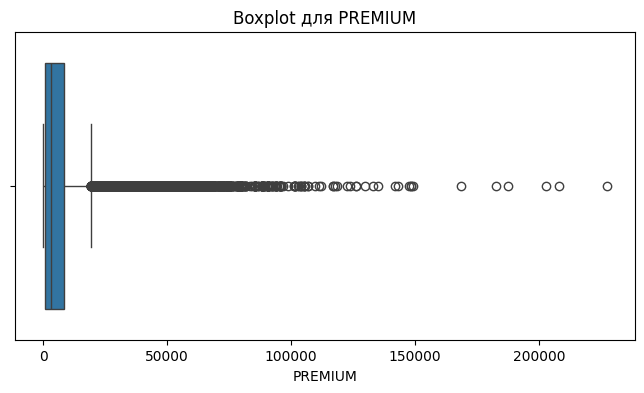

Колонка 'INSURED_VALUE':
Нижняя граница: -885000.00, верхняя граница: 1475000.00
Число выбросов: 17854 из 292434 строк (6.11%)



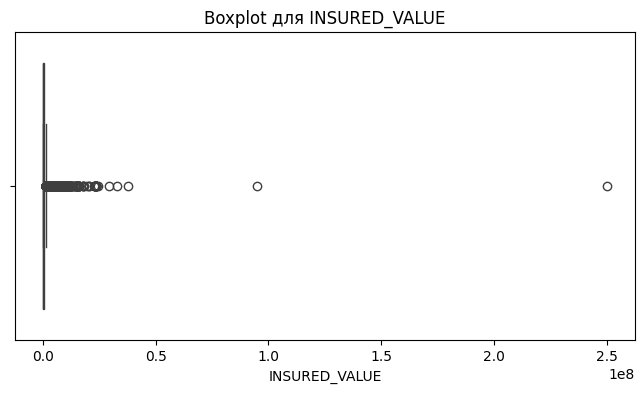

Колонка 'SEATS_NUM':
Нижняя граница: -3.50, верхняя граница: 8.50
Число выбросов: 42782 из 292434 строк (14.63%)



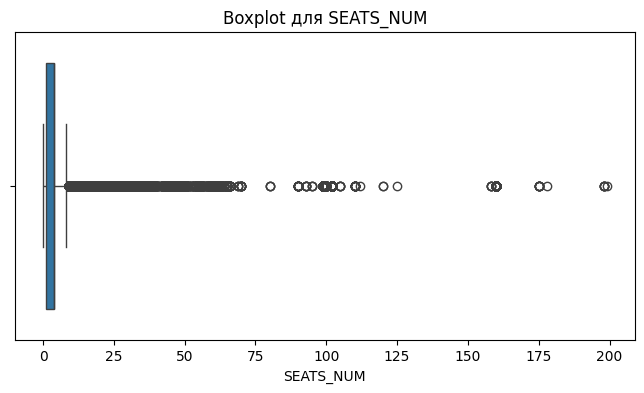

Колонка 'CARRYING_CAPACITY':
Нижняя граница: -9.00, верхняя граница: 23.00
Число выбросов: 65817 из 292434 строк (22.51%)



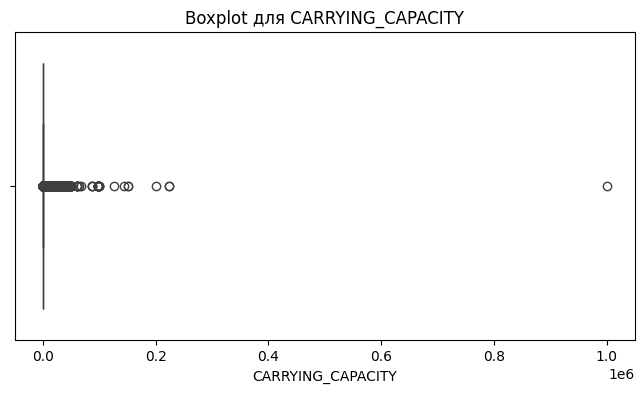

Колонка 'CCM_TON':
Нижняя граница: -3753.50, верхняя граница: 8914.50
Число выбросов: 28864 из 292434 строк (9.87%)



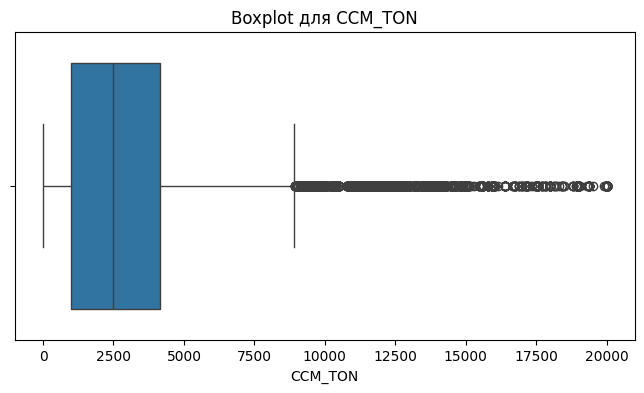

Колонка 'PROD_YEAR':
Нижняя граница: 1972.50, верхняя граница: 2032.50
Число выбросов: 3803 из 292434 строк (1.30%)



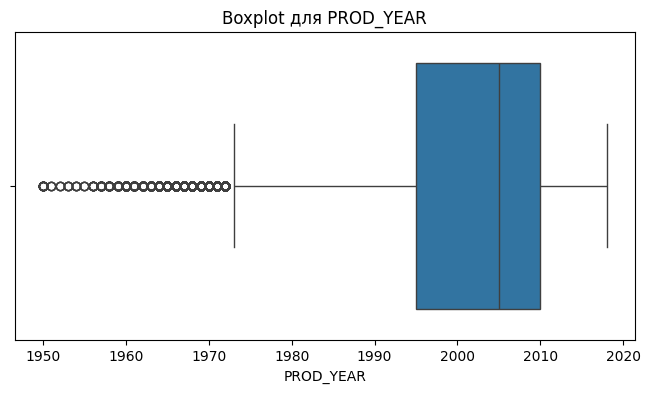

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in numeric_cols:
  lower_bound, upper_bound = IQR(motor_data_11_14_copy, col)
  outliers = motor_data_11_14_copy[(motor_data_11_14_copy[col] < lower_bound) |
                                 (motor_data_11_14_copy[col] > upper_bound)]

  print(f"Колонка '{col}':")
  print(f"Нижняя граница: {lower_bound:.2f}, верхняя граница: {upper_bound:.2f}")
  print(f"Число выбросов: {len(outliers)} из {len(motor_data_11_14_copy)} строк ({len(outliers)/len(motor_data_11_14_copy)*100:.2f}%)\n")

  # Визуализация распределения и выбросов
  plt.figure(figsize=(8,4))
  sns.boxplot(x=motor_data_11_14[col])
  plt.title(f"Boxplot для {col}")
  plt.show()

In [77]:
numeric_cols = ['PREMIUM', 'INSURED_VALUE', 'SEATS_NUM',
                'CARRYING_CAPACITY', 'CCM_TON', 'CLAIM_PAID', 'PROD_YEAR']

motor_data_11_14_copy[numeric_cols].corr().round(2)

,PREMIUM,INSURED_VALUE,SEATS_NUM,CARRYING_CAPACITY,CCM_TON,CLAIM_PAID,PROD_YEAR
PREMIUM,1.00,0.55,0.13,0.11,0.40,0.07,0.27
INSURED_VALUE,0.55,1.00,-0.00,0.08,0.26,0.03,0.26
SEATS_NUM,0.13,-0.00,1.00,-0.05,0.13,0.01,-0.03
CARRYING_CAPACITY,0.11,0.08,-0.05,1.00,0.11,0.01,0.03
CCM_TON,0.40,0.26,0.13,0.11,1.00,0.03,0.04
CLAIM_PAID,0.07,0.03,0.01,0.01,0.03,1.00,0.02
PROD_YEAR,0.27,0.26,-0.03,0.03,0.04,0.02,1.00


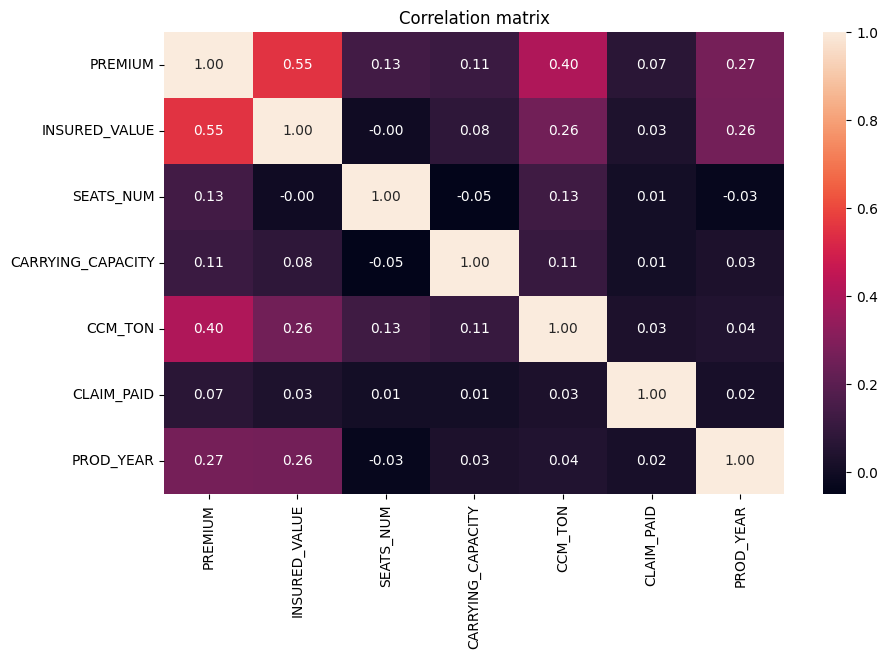

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(
    motor_data_11_14_copy[numeric_cols].corr(),
    annot=True,
    fmt=".2f"
)
plt.title("Correlation matrix")
plt.show()

Анализ матрицы корреляции показал, что сильные линейные зависимости между признаками отсутствуют. Наиболее выраженная связь наблюдается между страховой премией и страховой стоимостью (0.55), что подтверждает логическую согласованность данных. Отсутствует мультиколлинеарность признаков. 

# **2.2 Применение методов построения ассоциативных правил**

In [79]:
df_fp = motor_data_11_14_copy.copy()

# разбиваем на 3 категории
df_fp['PREMIUM_BIN'] = pd.qcut(df_fp['PREMIUM'], 3, labels=['Low', 'Medium', 'High'])
df_fp['INSURED_VALUE_BIN'] = pd.cut(df_fp['INSURED_VALUE'], 3, labels=['Low', 'Medium', 'High'])
df_fp['CCM_TON_BIN'] = pd.qcut(df_fp['CCM_TON'], 3, labels=['Low', 'Medium', 'High'])
df_fp['PROD_YEAR_BIN'] = pd.qcut(df_fp['PROD_YEAR'], 3, labels=['Old', 'Mid', 'New'])

In [80]:
df_fp['CLAIM_FLAG'] = df_fp['CLAIM_PAID'].apply(lambda x: 'Yes' if x > 0 else 'No')

In [81]:
features = [
    'SEX',
    'TYPE_VEHICLE',
    'MAKE',
    'USAGE',
    'PREMIUM_BIN',
    'INSURED_VALUE_BIN',
    'CCM_TON_BIN',
    'PROD_YEAR_BIN',
    'CLAIM_FLAG'
]

df_fp = df_fp[features].astype(str)
df_fp = df_fp.apply(lambda x: x.name + '=' + x)

In [82]:
transactions = df_fp.values.tolist()

te = TransactionEncoder()
te_ary = te.fit_transform(transactions)

df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

In [83]:
frequent_itemsets_fp = fpgrowth(df_encoded, min_support=0.2, use_colnames=True)
rules = association_rules(frequent_itemsets_fp, metric="support", min_threshold=0.2)
good_rules = rules.sort_values(by='lift', ascending=False)

good_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5)

,antecedents,consequents,support,confidence,lift
81,(USAGE=Own Goods),"(SEX=0, CLAIM_FLAG=No)",0.248429,0.850322,1.622588
76,"(SEX=0, CLAIM_FLAG=No)",(USAGE=Own Goods),0.248429,0.474052,1.622588
93,(USAGE=Own Goods),"(INSURED_VALUE_BIN=Low, SEX=0, CLAIM_FLAG=No)",0.248429,0.850322,1.622588
90,"(INSURED_VALUE_BIN=Low, USAGE=Own Goods)","(SEX=0, CLAIM_FLAG=No)",0.248429,0.850322,1.622588
87,"(SEX=0, CLAIM_FLAG=No)","(INSURED_VALUE_BIN=Low, USAGE=Own Goods)",0.248429,0.474052,1.622588


Ассоциативный анализ подтвердил логические зависимости между типом владельца (SEX=0 — юридическое лицо), страховыми выплатами, типом использования и страховой стоимостью. Высокие значения lift (>1.6) показывают действительную связь, а не совпадение.

**Добавление Feature Engineering**

Для того, чтобы дата не была в текстовом виде, нужно привести к правильному формату, при этом добавит новый признак: длительность используемой страховки, после этого нужно удалить бывшие признаки.

In [84]:
motor_data_11_14_copy['INSR_BEGIN'] = pd.to_datetime(motor_data_11_14_copy['INSR_BEGIN'], format='%d-%b-%y')
motor_data_11_14_copy['INSR_END'] = pd.to_datetime(motor_data_11_14_copy['INSR_END'], format='%d-%b-%y')

# Длительность страховки
motor_data_11_14_copy['INSR_DURATION_DAYS'] = (motor_data_11_14_copy['INSR_END'] - motor_data_11_14_copy['INSR_BEGIN']).dt.days

# Год и месяц начала
motor_data_11_14_copy['INSR_BEGIN_YEAR'] = motor_data_11_14_copy['INSR_BEGIN'].dt.year
motor_data_11_14_copy['INSR_BEGIN_MONTH'] = motor_data_11_14_copy['INSR_BEGIN'].dt.month

# Удаляем исходные колонки с датой и OBJECT_ID
motor_data_11_14_copy = motor_data_11_14_copy.drop(columns=['INSR_BEGIN', 'INSR_END', 'OBJECT_ID'])

# **3. Подготовка данных**

# **3.1 Обработка пропусков**

В прошлом пункте пропуски были обработаны. Пропуски в числовых данных были заменены на медианное значение, кроме столбца "CLAIM_PAID" - пропуски заменены на значение `0`. В категориальных данных не было допущено пропусков, кроме как в столбце "EFFECTIVE_YR". В этом столбце пропуск заменю на значение "unknown"

In [85]:
motor_data_11_14_copy["EFFECTIVE_YR"] = motor_data_11_14_copy["EFFECTIVE_YR"].fillna("unknown")

In [86]:
motor_data_11_14_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 292434 entries, 0 to 293536
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   SEX                 292434 non-null  int64  
 1   EFFECTIVE_YR        292434 non-null  object 
 2   INSR_TYPE           292434 non-null  int64  
 3   INSURED_VALUE       292434 non-null  float64
 4   PREMIUM             292434 non-null  float64
 5   PROD_YEAR           292434 non-null  float64
 6   SEATS_NUM           292434 non-null  float64
 7   CARRYING_CAPACITY   292434 non-null  float64
 8   TYPE_VEHICLE        292434 non-null  object 
 9   CCM_TON             292434 non-null  float64
 10  MAKE                292434 non-null  object 
 11  USAGE               292434 non-null  object 
 12  CLAIM_PAID          292434 non-null  float64
 13  INSR_DURATION_DAYS  292434 non-null  int64  
 14  INSR_BEGIN_YEAR     292434 non-null  int32  
 15  INSR_BEGIN_MONTH    292434 non-null  in

In [87]:
motor_data_11_14_copy['CLAIM_PAID'] = motor_data_11_14_copy['CLAIM_PAID'].apply(lambda x: 'Yes' if x > 0 else 'No')

# **3.2 Обработка категориальных переменных**

`Категориальные переменные` - 'SEX', 'TYPE_VEHICLE', 'MAKE', 'USAGE'

In [88]:
ohe_columns = ['SEX', 'TYPE_VEHICLE', 'MAKE', 'USAGE', 'EFFECTIVE_YR']
num_columns = ['PREMIUM', 'INSURED_VALUE', 'SEATS_NUM', 'CARRYING_CAPACITY', 'CCM_TON', 'PROD_YEAR', 'INSR_DURATION_DAYS', 'INSR_BEGIN_YEAR', 'INSR_BEGIN_MONTH']
ohe_pipe = Pipeline([
    (
        'SimpleImputer_ohe',
        SimpleImputer(missing_values = np.nan, strategy='most_frequent')
    ),
    (
        'ohe',
        OneHotEncoder(handle_unknown='ignore', drop='first')
    )
])

# **3.3 Обработка числовых переменных**

In [89]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('num', StandardScaler(), num_columns)
    ],
    remainder='passthrough'
)

# **4. Обучение моделей**

In [90]:
X = motor_data_11_14_copy.drop(['CLAIM_PAID'], axis=1)
y = motor_data_11_14_copy['CLAIM_PAID']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [91]:
pipeline_rf = Pipeline(
    [('preprocessor', data_preprocessor),
     ('models', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'))
     ]
)

In [92]:
pipeline_mlp = Pipeline(
    [('preprocessor', data_preprocessor),
     ('models', MLPClassifier(hidden_layer_sizes=(64,32), max_iter=100, random_state=RANDOM_STATE))
     ]
)

In [93]:
pipeline_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('models', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [95]:
pipeline_mlp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('models', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

Выполнена кодировка категориальных признаков, а также обработка числовых переменных. Обучены две модели - модель случайного леса (ансамблевый подход) и нейронные сети.

# **5. Валидация модели**

Я использовала оценку качества моделей - Hold-out. Перед этим разделила датасет на тренировочную и тестовую выборку в пропорции (80% - тренировочная, 20% - тестовая от всего объема данных). 

Для оценки качества работы моделей используется инструмент `classification_report` из библиотеки `scikit-learn`, который выводит полный текстовый отчет классификации основными метриками для каждого класса. И метрика ROC-AUC.

In [96]:
#функция оценки качества моделей
def evaluate_model(pipeline, X_test, y_test, model_name="Model"):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    print(f"{model_name}")
    print(classification_report(y_test, y_pred))
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC: {roc_auc:.4f}")
    
    return {
        "f1_weighted": f1_score(y_test, y_pred, average='weighted'),
        "roc_auc": roc_auc
    }

rf_metrics = evaluate_model(pipeline_rf, X_test, y_test, "RandomForest")
mlp_metrics = evaluate_model(pipeline_mlp, X_test, y_test, "MLP")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


RandomForest
              precision    recall  f1-score   support

          No       0.93      0.95      0.94     54050
         Yes       0.22      0.16      0.18      4437

    accuracy                           0.89     58487
   macro avg       0.57      0.56      0.56     58487
weighted avg       0.88      0.89      0.89     58487

ROC-AUC: 0.7313


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


MLP


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

          No       0.92      1.00      0.96     54050
         Yes       0.00      0.00      0.00      4437

    accuracy                           0.92     58487
   macro avg       0.46      0.50      0.48     58487
weighted avg       0.85      0.92      0.89     58487

ROC-AUC: 0.7726


In [47]:
def save_model_version(pipeline, metrics, model_type):
    version = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_path = f"models/{model_type}_{version}.pkl"
    os.makedirs("models", exist_ok=True)
    
    # Сохранение модели
    joblib.dump(pipeline, model_path)
    
    # Сохранение метаданных (контроль качества)
    metadata = {
        "version": version,
        "metrics": metrics,
        "model_path": model_path
    }
    with open(f"models/log_{model_type}.json", "a") as f:
        f.write(json.dumps(metadata) + "\n")
    
    print(f"Модель {model_type} сохранена как {model_path}")

save_model_version(pipeline_rf, rf_metrics, "RF")
save_model_version(pipeline_mlp, mlp_metrics, "MLP")

Модель RF сохранена как models/RF_20260323_185136.pkl


# **6. Обслуживание модели**

In [48]:
# Выбор лучшей модели (например, по ROC-AUC)
final_model = pipeline_rf if rf_metrics['roc_auc'] > mlp_metrics['roc_auc'] else pipeline_mlp
joblib.dump(final_model, 'final_model.pkl')

['final_model.pkl']

Происходит выбор и упаковка модели, которая показала лучшее качество по метрике ROC-AUC на тестовых данных.

# **7. Управление программой**

In [ ]:
class ModelManager:
    def __init__(self, model_path='final_model.pkl'):
        self.model = joblib.load(model_path)
    
    def predict(self, data):
        #Inference: предсказание для новых данных
        return self.model.predict(data)
    
    def update(self, X_new, y_new):
        #Update: дообучение (или переобучение) модели
        print("Переобучение модели на новых данных")
        self.model.fit(X_new, y_new)
        joblib.dump(self.model, 'final_model.pkl')
        
    def summary(self):
        #Summary: информация о структуре пайплайна
        return str(self.model.named_steps)